<a href="https://colab.research.google.com/github/clobos/Alimentos_2026/blob/main/semana01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Meu primeiro código em Python

Faça alguma descrição...

## Nada é bom

Algum  texto legal...

$a^2+b^2=c^2$


### Carregando um arquivo XLSX

Para carregar um arquivo `.xlsx`, você precisará primeiro fazer o upload para o ambiente do Colab (se ainda não o fez). Você pode arrastar e soltar o arquivo para a aba de arquivos à esquerda ou usar o seguinte código para fazer o upload:

# Arrumando a base de dados

In [16]:
import pandas as pd
df = pd.read_excel('dados.xlsx')

# 1. Reduzir o nome de cada variável para uma ou duas palavras.
new_column_names = {
    'Carimbo de data/hora': 'Data_Hora',
    'Nome ou apelido': 'Nome',
    'Curso': 'Curso',
    'Quantos cafés você consumiu nas últimas 24 horas?': 'Cafes_24h',
    'Qual é a temperatura ideal, em °C, para beber café filtrado?': 'Temp_Cafe',
    'Qual dessas frutas você prefere para suco natural?': 'Fruta_Suco',
    'Como você classificaria o nível de doçura ideal de um iogurte?': 'Docura_Iogurte',
    'Quantas refeições você faz por dia, em média?': 'Refeicoes_Dia',
    'Qual foi o peso, em gramas, da última porção de arroz que você consumiu?': 'Peso_Arroz_g',
    'Qual tipo de dieta você segue atualmente?': 'Tipo_Dieta',
    'Como você avalia sua preferência por alimentos crocantes?': 'Crocancia',
    'Quanto tempo, em minutos, você normalmente leva para preparar o café da manhã?': 'Tempo_Cafe_Manha'
}
df = df.rename(columns=new_column_names)

# 2. Padronizar respostas das colunas, tirando números e textos das colunas.

# Function to extract numeric values from a series (e.g., '10 minutos' -> 10.0)
def extract_numeric(series):
    # Convert to string, replace comma with dot for decimals, then extract the first sequence of digits/decimals
    return series.astype(str).str.replace(',', '.').str.extract(r'(\d+\.?\d*)', expand=False).astype(float)

# Columns that are expected to be numerical but might contain text
numeric_cols_to_clean = [
    'Cafes_24h',
    'Temp_Cafe',
    'Refeicoes_Dia',
    'Peso_Arroz_g',
    'Tempo_Cafe_Manha'
]

for col in numeric_cols_to_clean:
    if col in df.columns:
        # Apply extraction only if the column is of object type (contains strings/mixed types)
        if df[col].dtype == 'object':
            df[col] = extract_numeric(df[col])

# Columns that contain categorical text and need standardization (e.g., lowercasing, stripping whitespace)
categorical_cols_to_clean_text = [
    'Nome',
    'Curso',
    'Fruta_Suco',
    'Docura_Iogurte',
    'Tipo_Dieta'
]

for col in categorical_cols_to_clean_text:
    if col in df.columns:
        # Apply text cleaning only if the column is of object type
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.lower().str.strip()

# Display the first few rows of the cleaned DataFrame and its info to show changes
display(df.head(6))
display(df.info())

,Data_Hora,Nome,Curso,Cafes_24h,Temp_Cafe,Fruta_Suco,Docura_Iogurte,Refeicoes_Dia,Peso_Arroz_g,Tipo_Dieta,Crocancia,Tempo_Cafe_Manha
0,2026-08-03 19:11:11.422,gustavo,ciência dos alimentos,0.0,0.0,manga,baixo,2.0,200.0,onívora,3,0.0
1,2026-08-03 19:11:16.191,laura,ciência dos alimentos,0.0,70.0,maracujá,médio,4.0,100.0,outra,3,30.0
2,2026-08-03 19:11:31.786,nayara,ciência dos alimentos,0.0,40.0,laranja,médio,4.0,100.0,onívora,4,10.0
3,2026-08-03 19:11:34.070,lais,ciência dos alimentos,0.0,50.0,laranja,baixo,3.0,100.0,onívora,5,20.0
4,2026-08-03 19:12:04.182,nan,ciência dos alimentos,6.0,30.0,melancia,médio,5.0,70.0,onívora,5,30.0
5,2026-08-03 19:12:12.199,karin,ciência dos alimentos,1.0,55.0,morango,baixo,4.0,200.0,vegetariana,5,30.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Data_Hora         24 non-null     datetime64[ns]
 1   Nome              24 non-null     object        
 2   Curso             24 non-null     object        
 3   Cafes_24h         22 non-null     float64       
 4   Temp_Cafe         24 non-null     float64       
 5   Fruta_Suco        24 non-null     object        
 6   Docura_Iogurte    24 non-null     object        
 7   Refeicoes_Dia     21 non-null     float64       
 8   Peso_Arroz_g      22 non-null     float64       
 9   Tipo_Dieta        24 non-null     object        
 10  Crocancia         24 non-null     int64         
 11  Tempo_Cafe_Manha  24 non-null     float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(5)
memory usage: 2.4+ KB


None

In [17]:
display(df.tail(6))

,Data_Hora,Nome,Curso,Cafes_24h,Temp_Cafe,Fruta_Suco,Docura_Iogurte,Refeicoes_Dia,Peso_Arroz_g,Tipo_Dieta,Crocancia,Tempo_Cafe_Manha
18,2026-08-03 19:13:31.536,yasmin agatha,ciência dos alimentos,1.0,75.0,maracujá,médio,2.0,300.0,onívora,5,5.0
19,2026-08-03 19:13:50.467,yasmin monteiro,ciência dos alimentos,0.0,50.0,laranja,médio,4.0,250.0,onívora,4,10.0
20,2026-08-03 19:14:55.955,yasmin almeida,ciência dos alimentos,2.0,50.0,laranja,médio,3.0,300.0,onívora,4,2.0
21,2026-08-03 19:15:10.643,mei,ciência dos alimentos,0.0,35.0,laranja,médio,3.0,50.0,onívora,4,10.0
22,2026-08-03 19:15:27.732,maria eduarda,ciência dos alimentos,NaN,65.0,maracujá,baixo,3.0,80.0,onívora,1,20.0
23,2026-08-03 19:15:47.631,iago santos,ciência dos alimentos,1.0,65.0,laranja,médio,3.0,200.0,onívora,5,5.0


/tmp/ipykernel_3493/2647340678.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fruta', y='Contagem', data=fruit_counts, palette='viridis')


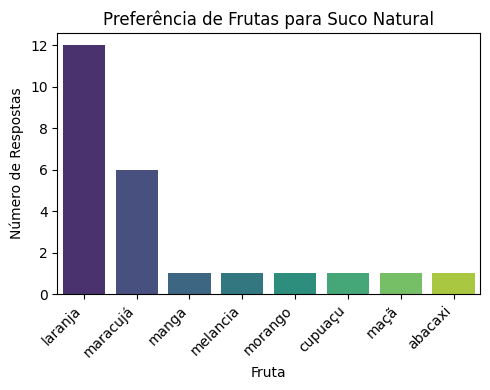

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Defina o nome da coluna de interesse
column_name = "Fruta_Suco"

# Verifique se a coluna existe no DataFrame
if column_name in df.columns:
    # Conte a frequência de cada fruta
    fruit_counts = df[column_name].value_counts().reset_index()
    fruit_counts.columns = ['Fruta', 'Contagem']

    # Crie o gráfico de barras
    plt.figure(figsize=(5, 4))
    sns.barplot(x='Fruta', y='Contagem', data=fruit_counts, palette='viridis')
    plt.title('Preferência de Frutas para Suco Natural')
    plt.xlabel('Fruta')
    plt.ylabel('Número de Respostas')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"A coluna '{column_name}' não foi encontrada no DataFrame. Verifique o nome da coluna.")

In [21]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Data_Hora         24 non-null     datetime64[ns]
 1   Nome              24 non-null     object        
 2   Curso             24 non-null     object        
 3   Cafes_24h         22 non-null     float64       
 4   Temp_Cafe         24 non-null     float64       
 5   Fruta_Suco        24 non-null     object        
 6   Docura_Iogurte    24 non-null     object        
 7   Refeicoes_Dia     21 non-null     float64       
 8   Peso_Arroz_g      22 non-null     float64       
 9   Tipo_Dieta        24 non-null     object        
 10  Crocancia         24 non-null     int64         
 11  Tempo_Cafe_Manha  24 non-null     float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(5)
memory usage: 2.4+ KB


# Tipos de variáveis

## Qual. nominal

## Qual. ordinal

## Quant. Discreta

## Quant. Continua

# Duas perguntas

## Pergunta 1

## Pergunta 2